In [2]:
from typing import Literal

import torch
from scvi import REGISTRY_KEYS
from scvi.module.base import (
    BaseModuleClass,
    LossOutput,
    auto_move_data,
)
from torch.distributions import NegativeBinomial, Normal
from torch.distributions import kl_divergence as kl
import scvi

In [7]:
class MyNeuralNet(torch.nn.Module):
    def __init__(
        self,
        n_input: int,
        n_output: int,
        link_var: Literal["exp", "none", "softmax"],
    ):
        """
        Encodes data of ``n_input`` dimensions into a space of ``n_output`` dimensions.

        Uses a one layer fully-connected neural network with 128 hidden nodes.

        Parameters
        ----------
        n_input
            The dimensionality of the input
        n_output
            The dimensionality of the output
        link_var
            The final non-linearity
        """
        super().__init__()
        self.neural_net = torch.nn.Sequential(
            torch.nn.Linear(n_input, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, n_output),
        )
        self.transformation = None
        if link_var == "softmax":
            self.transformation = torch.nn.Softmax(dim=-1)
        elif link_var == "exp":
            self.transformation = torch.exp

    def forward(self, x: torch.Tensor):
        output = self.neural_net(x)
        if self.transformation:
            output = self.transformation(output)
        return output

In [ ]:
class base_module(BaseModuleClass):
    """
    Skeleton Variational auto-encoder model.

    Here we implement a basic version of scVI's underlying VAE [Lopez18]_.
    This implementation is for instructional purposes only.

    Parameters
    ----------
    n_input
        Number of input genes
    n_latent
        Dimensionality of the latent space
    """

    def __init__(
        self,
        n_input: int,
        n_latent: int = 10,
    ):
        super().__init__()
        # in the init, we create the parameters of our elementary stochastic computation unit.

        # First, we setup the parameters of the generative model
        self.decoder = MyNeuralNet(n_latent, n_input, "softmax")
        self.log_theta = torch.nn.Parameter(torch.randn(n_input))

        # Second, we setup the parameters of the variational distribution
        self.mean_encoder = MyNeuralNet(n_input, n_latent, "none")
        self.var_encoder = MyNeuralNet(n_input, n_latent, "exp")

    def _get_inference_input(self, tensors):
        """Parse the dictionary to get appropriate args"""
        # let us fetch the raw counts, and add them to the dictionary
        x = tensors[REGISTRY_KEYS.X_KEY]

        input_dict = dict(x=x)
        return input_dict

    @auto_move_data
    def inference(self, x):
        """
        High level inference method.

        Runs the inference (encoder) model.
        """
        # log the input to the variational distribution for numerical stability
        x_ = torch.log(1 + x)
        # get variational parameters via the encoder networks
        qz_m = self.mean_encoder(x_)
        qz_v = self.var_encoder(x_)
        # get one sample to feed to the generative model
        # under the hood here is the Reparametrization trick (Rsample)
        z = Normal(qz_m, torch.sqrt(qz_v)).rsample()

        outputs = dict(qz_m=qz_m, qz_v=qz_v, z=z)
        return outputs

    def _get_generative_input(self, tensors, inference_outputs):
        z = inference_outputs["z"]
        x = tensors[REGISTRY_KEYS.X_KEY]
        # here we extract the number of UMIs per cell as a known quantity - library size
        library = torch.sum(x, dim=1, keepdim=True)

        input_dict = {
            "z": z,
            "library": library,
        }
        return input_dict

    @auto_move_data
    def generative(self, z, library):
        """Runs the generative model."""

        # get the "normalized" mean of the negative binomial
        px_scale = self.decoder(z)
        # get the mean of the negative binomial
        px_rate = library * px_scale
        # get the dispersion parameter
        theta = torch.exp(self.log_theta)

        return dict(px_scale=px_scale, theta=theta, px_rate=px_rate)

    def loss(
        self,
        tensors,
        inference_outputs,
        generative_outputs,
    ):
        # here, we would like to form the ELBO. There are two terms:
        #   1. one that pertains to the likelihood of the data
        #   2. one that pertains to the variational distribution
        # so we extract all the required information
        x = tensors[REGISTRY_KEYS.X_KEY]
        px_rate = generative_outputs["px_rate"]
        theta = generative_outputs["theta"]
        qz_m = inference_outputs["qz_m"]
        qz_v = inference_outputs["qz_v"]

        # term 1
        # the pytorch NB distribution uses a different parameterization
        # so we must apply a quick transformation (included in scvi-tools, but here we use the pytorch code)
        nb_logits = (px_rate + 1e-4).log() - (theta + 1e-4).log()
        log_lik = (
            NegativeBinomial(total_count=theta, logits=nb_logits)
            .log_prob(x)
            .sum(dim=-1)
        )

        # term 2
        prior_dist = Normal(torch.zeros_like(qz_m), torch.ones_like(qz_v))
        var_post_dist = Normal(qz_m, torch.sqrt(qz_v))
        kl_divergence = kl(var_post_dist, prior_dist).sum(dim=1)

        elbo = log_lik - kl_divergence
        loss = torch.mean(-elbo)
        return LossOutput(loss=loss, recon_loss=-torch.mean(log_lik), kl_loss=torch.mean(kl_divergence))

In [3]:
from typing import Optional, Sequence

import numpy as np
import scvi
import torch
from anndata import AnnData
from scvi import REGISTRY_KEYS
from scvi.data import AnnDataManager
from scvi.data.fields import (
    CategoricalJointObsField,
    CategoricalObsField,
    LayerField,
    NumericalJointObsField,
    NumericalObsField,
)
from scvi.model.base import BaseModelClass, UnsupervisedTrainingMixin, VAEMixin
from scvi.module import VAE

In [5]:
class SCVI(VAEMixin, UnsupervisedTrainingMixin, BaseModelClass):
    """
    single-cell Variational Inference [Lopez18]_.
    """

    def __init__(
        self,
        adata: AnnData,
        n_latent: int = 10,
        **model_kwargs,
    ):
        super().__init__(adata)

        self.module = VAE(
            n_input=self.summary_stats["n_vars"],
            n_batch=self.summary_stats["n_batch"],
            n_latent=n_latent,
            **model_kwargs,
        )
        self._model_summary_string = (
            "SCVI Model with the following params: \nn_latent: {}"
        ).format(
            n_latent,
        )
        self.init_params_ = self._get_init_params(locals())

    @classmethod
    def setup_anndata(
        cls,
        adata: AnnData,
        batch_key: Optional[str] = None,
        layer: Optional[str] = None,
        **kwargs,
    ) -> Optional[AnnData]:
        setup_method_args = cls._get_setup_method_args(**locals())
        anndata_fields = [
            LayerField(REGISTRY_KEYS.X_KEY, layer, is_count_data=True),
            CategoricalObsField(REGISTRY_KEYS.BATCH_KEY, batch_key),
            # Dummy fields required for VAE class.
            CategoricalObsField(REGISTRY_KEYS.LABELS_KEY, None),
            NumericalObsField(REGISTRY_KEYS.SIZE_FACTOR_KEY, None, required=False),
            CategoricalJointObsField(REGISTRY_KEYS.CAT_COVS_KEY, None),
            NumericalJointObsField(REGISTRY_KEYS.CONT_COVS_KEY, None),
        ]
        adata_manager = AnnDataManager(
            fields=anndata_fields, setup_method_args=setup_method_args
        )
        adata_manager.register_fields(adata, **kwargs)
        cls.register_manager(adata_manager)

In [6]:
from kiara.datasets.kang import load_kang_data

adata, labels_key, control_label = load_kang_data()

/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/kiara/datasets/kang.py:43: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["cell_abbr"] = adata.obs["cell_type"].replace(abbreviations)


In [14]:
SCVI.setup_anndata(adata, batch_key="condition")
print(f"adata UUID (assigned by setup_anndata): {adata.uns['_scvi_uuid']}")
print(f"AnnDataManager: {SCVI._setup_adata_manager_store[adata.uns['_scvi_uuid']]}")
model = SCVI(adata)
model

adata UUID (assigned by setup_anndata): 284cdaa5-e652-4995-b549-6b67e00382ee
AnnDataManager: <scvi.data._manager.AnnDataManager object at 0x7ffebcd5f070>


/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


SCVI Model with the following params: 
n_latent: 10
Training status: Not Trained

In [15]:
model.train(max_epochs=400)

/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/benchmark ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/benchmark ...
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_mat

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [16]:
model.save("/g/stegle/spiljak/tutorial_model/my_VAE/scvi_base_model/", save_anndata=True)

In [7]:
scvi_model = SCVI.load("/g/stegle/spiljak/tutorial_model/my_VAE/scvi_base_model/")

INFO     File /g/stegle/spiljak/tutorial_model/my_VAE/scvi_base_model/model.pt already downloaded                  


/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/benchmark ...
/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
scvi_model.get_latent_representation()  # latent space for all cells in validation set

array([[-1.3943429 , -0.40448135, -0.9910359 , ..., -1.0896297 ,
         1.4391426 , -0.17609215],
       [-0.20260376,  0.6166508 ,  0.98819137, ..., -1.4884152 ,
        -1.4349322 , -0.9061047 ],
       [ 0.5104983 ,  0.76864284,  0.6182834 , ..., -1.1937969 ,
         0.15572572, -0.5104642 ],
       ...,
       [ 0.9918959 , -0.07629508,  0.5363493 , ...,  0.66945034,
        -1.3454561 ,  0.38480678],
       [-0.32676676, -0.06223923, -1.529753  , ...,  1.116837  ,
        -0.28792107, -0.18849939],
       [ 1.4791038 ,  1.4790518 ,  0.10262185, ...,  0.53366977,
         0.16983384, -0.06909835]], shape=(17913, 10), dtype=float32)

In [13]:
latent = scvi_model.get_latent_representation()
import umap.umap_ as umap
import matplotlib.pyplot as plt
import scanpy as sc

# Compute UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.5, random_state=42)
latent_umap = reducer.fit_transform(latent)

# Store UMAP coordinates in adata.obs for visualization
adata.obsm["UMAP_1"] = latent_umap[:, 0]
adata.obsm["UMAP_2"] = latent_umap[:, 1]


/g/stegle/spiljak/programs/miniforge3/envs/benchmark2/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


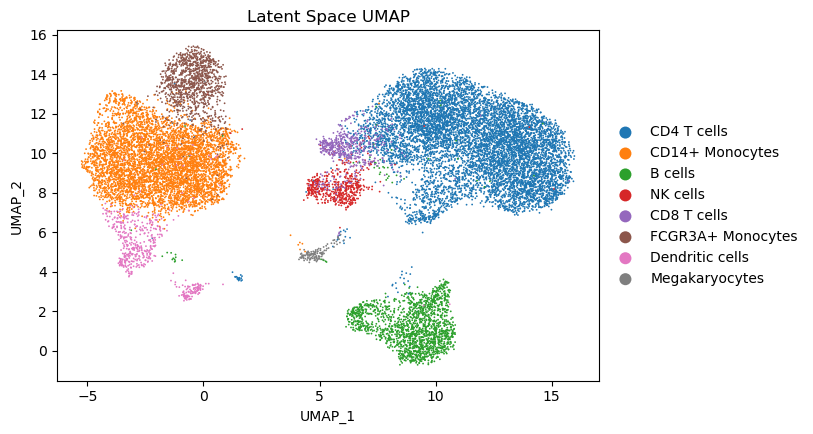

In [ ]:
sc.pl.scatter(
    adata,
    x="UMAP_1",
    y="UMAP_2",
    color="cell_type",  
    frameon=False,
    title="Latent Space UMAP",
)

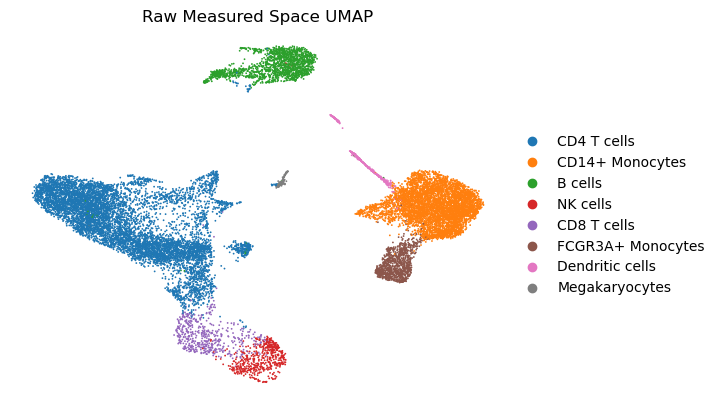

In [ ]:
# Plot UMAP colored by cell type
sc.pl.umap(
    adata,
    color="cell_type",  
    frameon=False,
    title="Raw Measured Space UMAP",
)

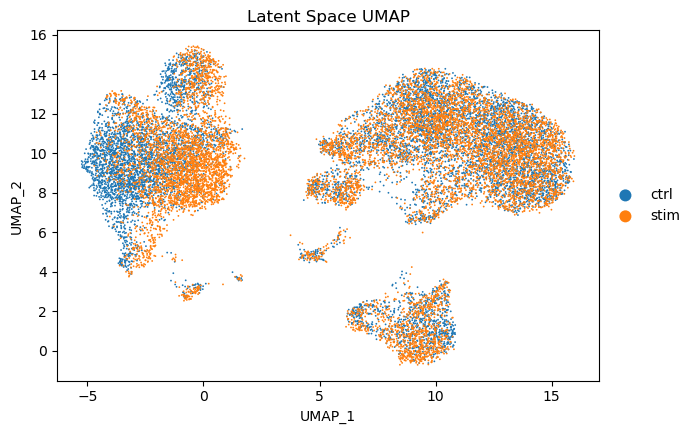

In [ ]:
sc.pl.scatter(
    adata,
    x="UMAP_1",
    y="UMAP_2",
    color="condition",  # Ime stupca u Obs po kojem žeiš da farba
    frameon=False,
    title="Latent Space UMAP",
)

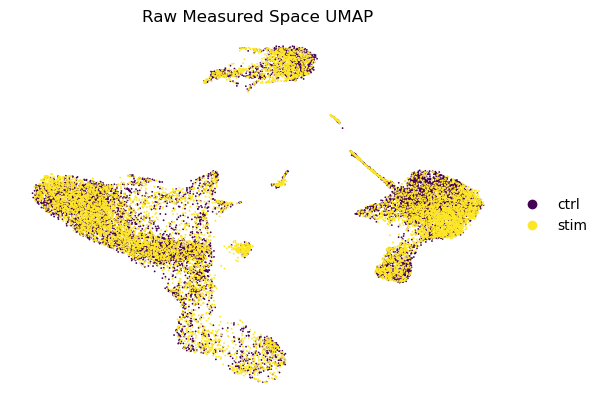

In [20]:
# Plot UMAP colored by condition
sc.pl.umap(
    adata,
    color="condition",  # Replace with your column
    palette="viridis",
    frameon=False,
    title="Raw Measured Space UMAP",
)

In [ ]:
# Check if 'latent' or 'model' already exist
print("latent" in globals())  # Should be False if fresh
print("model" in globals())   # Should be False if fresh

False
False
